In [ ]:
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent / "minio_utils"))

from minio_spark import MinioSparkClient
from os import getenv
from pyspark.sql import functions as F

import matplotlib.pyplot as plt
import polars as pl

In [2]:
client = MinioSparkClient(
    "https://minio.fdi.ucm.es",
    getenv("MINIO_ACCESS_KEY"),
    getenv("MINIO_SECRET_KEY"),
    "pd2/cityenjoyer",
    memory = 8,
    heapsize = 4,
    num_part = 1000
)
client.connect()

:: loading settings :: url = jar:file:/home/QuiSioU/UCM/y3/PD2/.venv/lib/python3.13/site-packages/pyspark/jars/ivy-2.5.3.jar!/org/apache/ivy/core/settings/ivysettings.xml
Ivy Default Cache set to: /home/QuiSioU/.ivy2.5.2/cache
The jars for the packages stored in: /home/QuiSioU/.ivy2.5.2/jars
org.apache.hadoop#hadoop-aws added as a dependency
:: resolving dependencies :: org.apache.spark#spark-submit-parent-745e5098-5c79-4ec3-b86d-6416ca3feb2e;1.0
	confs: [default]
	found org.apache.hadoop#hadoop-aws;3.4.1 in central
	found software.amazon.awssdk#bundle;2.24.6 in central
	found org.wildfly.openssl#wildfly-openssl;1.1.3.Final in central
:: resolution report :: resolve 109ms :: artifacts dl 4ms
	:: modules in use:
	org.apache.hadoop#hadoop-aws;3.4.1 from central in [default]
	org.wildfly.openssl#wildfly-openssl;1.1.3.Final from central in [default]
	software.amazon.awssdk#bundle;2.24.6 from central in [default]
	---------------------------------------------------------------------
	|     

In [3]:
df = client.read_parquet("21-25_merged.parquet")

SLF4J: Failed to load class "org.slf4j.impl.StaticLoggerBinder".
SLF4J: Defaulting to no-operation (NOP) logger implementation
SLF4J: See http://www.slf4j.org/codes.html#StaticLoggerBinder for further details.


In [ ]:
df.show(5)

Calculando métricas para: trip_distance...


Calculando métricas para: fare_amount...


Calculando métricas para: tip_amount...


Calculando métricas para: tolls_amount...


Calculando métricas para: total_amount...


Dibujando el gráfico...


/tmp/ipykernel_14734/2997115439.py:36: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.bxp(stats_para_graficar, showfliers=True, patch_artist=True,


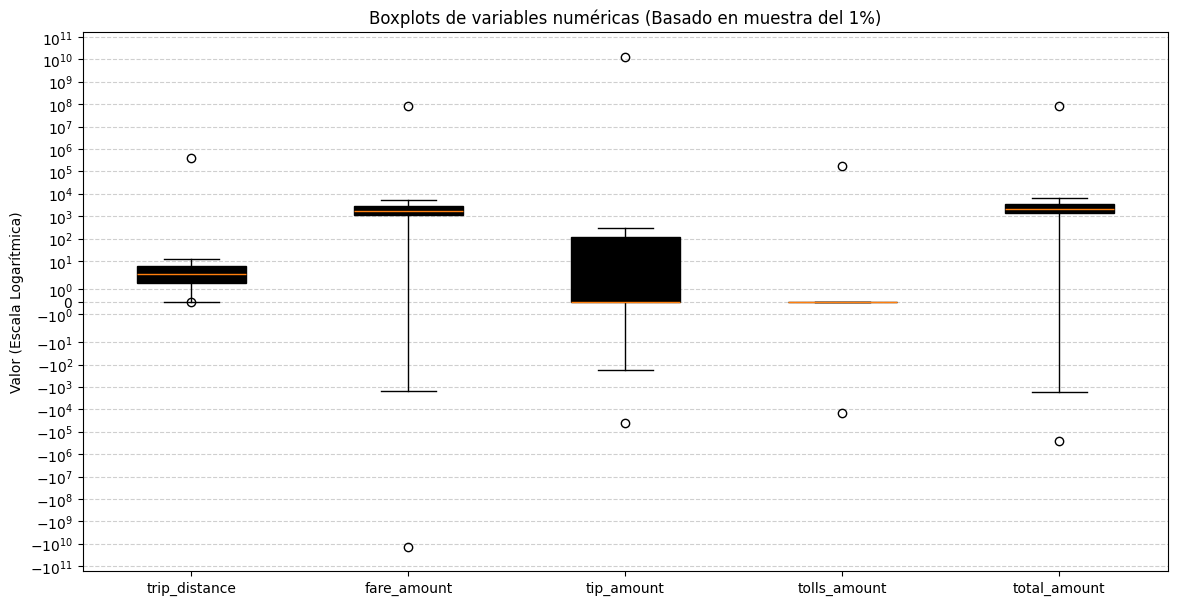

In [4]:
columnas_num = ["trip_distance", "fare_amount", "tip_amount", "tolls_amount", "total_amount"]
stats_para_graficar = []

for col in columnas_num:
    print(f"Calculando métricas para: {col}...")
    
    q1, med, q3 = df.approxQuantile(col, [0.25, 0.5, 0.75], 0.01)
    
    iqr = q3 - q1
    limite_inf = q1 - (1.5 * iqr)
    limite_sup = q3 + (1.5 * iqr)
    
    min_max = df.agg(F.min(col), F.max(col)).collect()[0]
    min_real = min_max[0]
    max_real = min_max[1]
    
    # Guardamos el resumen estadístico
    stats_para_graficar.append({
        'label': col,
        'med': med,
        'q1': q1,
        'q3': q3,
        'whislo': max(min_real, limite_inf),
        'whishi': min(max_real, limite_sup),
        'fliers': [float(min_real), float(max_real)] # Mostramos los valores extremos absolutos de la muestra
    })

# Liberamos la memoria caché de Spark
df.unpersist()

print("Dibujando el gráfico...")

# 3. Matplotlib dibuja las cajas instantáneamente usando solo los resúmenes matemáticos
fig, ax = plt.subplots(figsize=(14, 7))

ax.bxp(stats_para_graficar, showfliers=True, patch_artist=True, 
       boxprops=dict(facecolor='lightblue', color='black'))

# Escala logarítmica simétrica (symlog) para poder visualizar valores gigantes sin aplastar la caja
plt.yscale('symlog') 
plt.title("Boxplots de variables numéricas (Basado en muestra del 1%)")
plt.ylabel("Valor (Escala Logarítmica)")
plt.grid(axis='y', linestyle='--', alpha=0.6)

In [9]:
lf = pl.scan_parquet("../data/21-25_merged.parquet")
config = {
    "fare_amount":  (0, 10000),
    "tip_amount":   (0, 10000),
    "tolls_amount": (0, 5000),
    "total_amount": (0, 30000)
}

lf_final = lf.with_columns([
    pl.col("trip_distance").mul(1609.34).clip(0, 200 * 1609.34).cast(pl.Int32),
    *[pl.col(col).clip(low, high).cast(pl.Int16) for col, (low, high) in config.items()]
])

lf_final.sink_parquet("../data/21-25_clipped.parquet")